# Eksplorasi Data Cuaca untuk Prediksi Hujan 3 Jam ke Depan

Notebook ini mengeksplorasi data cuaca per jam dari Open-Meteo untuk wilayah Malang. Tujuan utamanya bukan hanya mendeskripsikan curah hujan, tetapi juga mencari pola yang berguna untuk membangun model prediksi kejadian hujan dalam tiga jam berikutnya.

Pertanyaan yang ingin dijawab:

1. Apakah data lengkap, konsisten, dan memiliki interval waktu yang benar?
2. Seberapa sering hujan terjadi dan apakah target prediksi tidak seimbang?
3. Kapan hujan paling sering terjadi: bulan, hari, atau jam tertentu?
4. Kondisi cuaca apa yang paling berhubungan dengan hujan tiga jam ke depan?
5. Apa implikasi hasil EDA terhadap feature engineering dan evaluasi model?

## 1. Setup dan konfigurasi

Konfigurasi lokasi, periode, dan ambang hujan ditempatkan di satu bagian agar eksperimen mudah direproduksi. Ambang `0.1 mm` digunakan untuk mendefinisikan sebuah kejadian hujan.

In [25]:
from __future__ import annotations

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

API_URL = "https://archive-api.open-meteo.com/v1/archive"
LATITUDE = -7.9666
LONGITUDE = 112.6326
START_DATE = "2025-09-01"
END_DATE = "2026-09-09"
TIMEZONE = "Asia/Jakarta"
RAIN_THRESHOLD_MM = 0.1
FORECAST_HORIZON_HOURS = 3

WEATHER_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "pressure_msl",
]

## 2. Mengambil data

Data diambil pada resolusi per jam. Respons API divalidasi sebelum diubah menjadi `DataFrame`, sehingga kegagalan pengambilan data tidak menghasilkan analisis yang diam-diam keliru.

In [26]:
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": WEATHER_COLUMNS,
    "timezone": TIMEZONE,
}

response = httpx.get(API_URL, params=params, timeout=30)
response.raise_for_status()
payload = response.json()

if "hourly" not in payload:
    raise ValueError(f"Respons API tidak memiliki data hourly: {payload}")

df_raw = pd.DataFrame(payload["hourly"])
print(f"Data mentah: {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
display(df_raw.head())

Data mentah: 8,976 baris x 9 kolom


,time,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,wind_direction_10m,pressure_msl
0,2025-09-01T00:00,20.200,94,0.000,0.000,11,2.100,345,"1,013.500"
1,2025-09-01T01:00,19.900,94,0.000,0.000,6,3.100,329,"1,012.800"
2,2025-09-01T02:00,19.500,92,0.000,0.000,13,3.200,313,"1,012.400"
3,2025-09-01T03:00,19.200,88,0.000,0.000,17,3.700,309,"1,012.400"
4,2025-09-01T04:00,18.900,84,0.000,0.000,32,3.700,313,"1,012.600"


## 3. Validasi dan penyiapan data

Bagian ini memeriksa kolom wajib, timestamp duplikat, jeda pada deret waktu, nilai hilang, dan cakupan data. Timestamp yang hilang dimunculkan kembali sebagai baris kosong agar operasi berbasis `shift` tidak salah menganggap dua observasi yang berjauhan sebagai jam yang berurutan.

In [27]:
required_columns = {"time", *WEATHER_COLUMNS}
missing_columns = sorted(required_columns.difference(df_raw.columns))

if missing_columns:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_columns}")

df = df_raw.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df[WEATHER_COLUMNS] = df[WEATHER_COLUMNS].apply(pd.to_numeric, errors="coerce")

invalid_timestamps = int(df["time"].isna().sum())
duplicate_timestamps = int(df["time"].duplicated().sum())

df = (
    df.dropna(subset=["time"])
    .sort_values("time")
    .drop_duplicates("time", keep="last")
)

expected_index = pd.date_range(
    start=df["time"].min(),
    end=df["time"].max(),
    freq="h",
    name="time",
)
missing_hour_count = int(len(expected_index) - len(df))

df = (
    df.set_index("time")
    .reindex(expected_index)
    .reset_index()
)

quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})

validation_summary = pd.Series({
    "periode_awal": df["time"].min(),
    "periode_akhir": df["time"].max(),
    "jumlah_jam_diharapkan": len(expected_index),
    "timestamp_tidak_valid": invalid_timestamps,
    "timestamp_duplikat": duplicate_timestamps,
    "timestamp_per_jam_yang_hilang": missing_hour_count,
    "cakupan_rain_pct": df["rain"].notna().mean() * 100,
})

display(validation_summary.to_frame("nilai"))
display(quality_report)

,nilai
periode_awal,2025-09-01 00:00:00
periode_akhir,2026-09-09 23:00:00
jumlah_jam_diharapkan,8976
timestamp_tidak_valid,0
timestamp_duplikat,0
timestamp_per_jam_yang_hilang,0
cakupan_rain_pct,100.000


,dtype,missing_count,missing_pct,unique_values
time,datetime64[ns],0,0.000,8976
temperature_2m,float64,0,0.000,158
relative_humidity_2m,int64,0,0.000,72
precipitation,float64,0,0.000,120
rain,float64,0,0.000,120
cloud_cover,int64,0,0.000,101
wind_speed_10m,float64,0,0.000,160
wind_direction_10m,int64,0,0.000,357
pressure_msl,float64,0,0.000,142


In [28]:
physical_checks = pd.Series({
    "rain_negatif": (df["rain"] < 0).sum(),
    "precipitation_negatif": (df["precipitation"] < 0).sum(),
    "humidity_di_luar_0_100": (df["relative_humidity_2m"].notna() & ~df["relative_humidity_2m"].between(0, 100)).sum(),
    "cloud_cover_di_luar_0_100": (df["cloud_cover"].notna() & ~df["cloud_cover"].between(0, 100)).sum(),
    "wind_speed_negatif": (df["wind_speed_10m"] < 0).sum(),
    "wind_direction_di_luar_0_360": (df["wind_direction_10m"].notna() & ~df["wind_direction_10m"].between(0, 360)).sum(),
})

print("Pemeriksaan rentang fisik (nilai 0 berarti tidak ada pelanggaran):")
display(physical_checks.to_frame("jumlah_baris"))

print("Statistik deskriptif:")
display(
    df[WEATHER_COLUMNS]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
)

Pemeriksaan rentang fisik (nilai 0 berarti tidak ada pelanggaran):


,jumlah_baris
rain_negatif,0
precipitation_negatif,0
humidity_di_luar_0_100,0
cloud_cover_di_luar_0_100,0
wind_speed_negatif,0
wind_direction_di_luar_0_360,0


Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
temperature_2m,"8,976.000",23.272,2.886,15.700,21.100,22.500,25.500,27.700,28.500,29.800,32.200
relative_humidity_2m,"8,976.000",82.440,15.499,25.000,72.000,88.000,95.000,98.000,99.000,100.000,100.000
precipitation,"8,976.000",0.329,1.322,0.000,0.000,0.000,0.100,0.600,1.500,6.900,28.500
rain,"8,976.000",0.329,1.322,0.000,0.000,0.000,0.100,0.600,1.500,6.900,28.500
cloud_cover,"8,976.000",73.164,34.562,0.000,44.000,96.000,100.000,100.000,100.000,100.000,100.000
wind_speed_10m,"8,976.000",4.311,2.641,0.000,2.400,3.800,5.700,8.100,9.600,12.200,19.400
wind_direction_10m,"8,976.000",215.645,91.635,2.000,133.000,241.000,300.000,315.000,327.000,351.000,360.000
pressure_msl,"8,976.000","1,011.907",2.364,"1,004.100","1,010.200","1,011.800","1,013.600","1,015.100","1,015.800","1,017.200","1,018.900"


## 4. Feature engineering dan definisi target

Target regresi adalah total curah hujan pada jam `t+1` sampai `t+3`. Target klasifikasi bernilai benar apabila total tersebut minimal `0.1 mm`. Tiga observasi terakhir—atau horizon lain yang tidak lengkap—dibiarkan kosong, bukan dilabeli sebagai tidak hujan. Ini mencegah label palsu.

In [29]:
df["hour"] = df["time"].dt.hour
df["day_of_week_num"] = df["time"].dt.dayofweek
df["day_of_week"] = df["time"].dt.day_name()
df["month"] = df["time"].dt.month
df["year_month"] = df["time"].dt.to_period("M").astype(str)

df["rain_event"] = df["rain"].ge(RAIN_THRESHOLD_MM).astype("boolean")
df.loc[df["rain"].isna(), "rain_event"] = pd.NA

future_rain_columns = [
    df["rain"].shift(-step).rename(f"rain_t_plus_{step}")
    for step in range(1, FORECAST_HORIZON_HOURS + 1)
]
future_rain = pd.concat(future_rain_columns, axis=1)

df["rain_next_3h_mm"] = future_rain.sum(
    axis=1,
    min_count=FORECAST_HORIZON_HOURS,
)
df["rain_event_next_3h"] = (
    df["rain_next_3h_mm"]
    .ge(RAIN_THRESHOLD_MM)
    .astype("boolean")
)
df.loc[df["rain_next_3h_mm"].isna(), "rain_event_next_3h"] = pd.NA

display(
    df[["time", "rain", "rain_next_3h_mm", "rain_event_next_3h"]]
    .tail(8)
)

,time,rain,rain_next_3h_mm,rain_event_next_3h
8968,2026-09-09 16:00:00,0.000,0.000,False
8969,2026-09-09 17:00:00,0.000,0.000,False
8970,2026-09-09 18:00:00,0.000,0.000,False
8971,2026-09-09 19:00:00,0.000,0.000,False
8972,2026-09-09 20:00:00,0.000,0.000,False
8973,2026-09-09 21:00:00,0.000,NaN,<NA>
8974,2026-09-09 22:00:00,0.000,NaN,<NA>
8975,2026-09-09 23:00:00,0.000,NaN,<NA>


## 5. Gambaran umum hujan dan keseimbangan target

Persentase kelas positif perlu dibandingkan dengan baseline kelas mayoritas. Akurasi model yang hanya sedikit lebih tinggi daripada baseline tersebut belum tentu berguna; metrik seperti precision, recall, F1, PR-AUC, dan ROC-AUC perlu dipertimbangkan.

,nilai
total_hujan_mm,"2,950.600"
jam_hujan,"2,718.000"
persentase_jam_hujan,30.281
rata_rata_hujan_saat_hujan_mm,1.086
hujan_maksimum_per_jam_mm,28.500
target_positif_pct,40.232
baseline_akurasi_kelas_mayoritas_pct,59.768


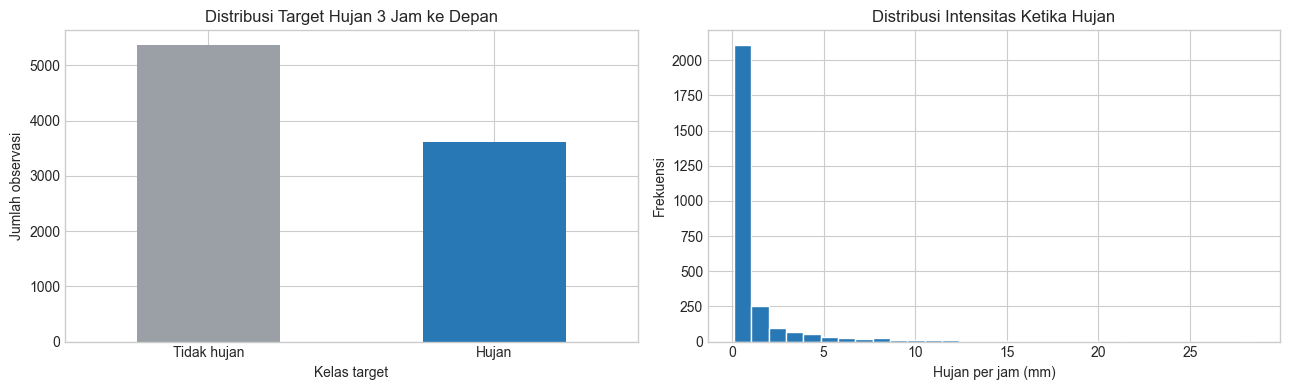

In [30]:
valid_current = df["rain_event"].dropna()
valid_target = df["rain_event_next_3h"].dropna()
positive_rate = float(valid_target.mean())
majority_baseline = max(positive_rate, 1 - positive_rate)

rain_summary = pd.Series({
    "total_hujan_mm": df["rain"].sum(min_count=1),
    "jam_hujan": int(valid_current.sum()),
    "persentase_jam_hujan": float(valid_current.mean()) * 100,
    "rata_rata_hujan_saat_hujan_mm": df.loc[df["rain_event"] == True, "rain"].mean(),
    "hujan_maksimum_per_jam_mm": df["rain"].max(),
    "target_positif_pct": positive_rate * 100,
    "baseline_akurasi_kelas_mayoritas_pct": majority_baseline * 100,
})
display(rain_summary.to_frame("nilai"))

target_distribution = (
    valid_target.value_counts()
    .rename(index={False: "Tidak hujan", True: "Hujan"})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
target_distribution.plot.bar(ax=axes[0], color=["#9aa0a6", "#2878b5"])
axes[0].set_title("Distribusi Target Hujan 3 Jam ke Depan")
axes[0].set_xlabel("Kelas target")
axes[0].set_ylabel("Jumlah observasi")
axes[0].tick_params(axis="x", rotation=0)

wet_values = df.loc[df["rain_event"] == True, "rain"]
axes[1].hist(wet_values, bins=30, color="#2878b5", edgecolor="white")
axes[1].set_title("Distribusi Intensitas Ketika Hujan")
axes[1].set_xlabel("Hujan per jam (mm)")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

## 6. Tren harian dan bulanan

Agregasi harian membantu memisahkan sinyal cuaca dari variasi per jam. Rata-rata bergerak 7 dan 30 hari digunakan untuk melihat perubahan jangka pendek dan kecenderungan yang lebih stabil. Bulan dengan cakupan kurang dari 90% tidak digunakan ketika menentukan bulan paling basah atau paling kering.

In [31]:
daily = (
    df.set_index("time")
    .resample("D")
    .agg(
        rain_mm=("rain", lambda values: values.sum(min_count=1)),
        observed_hours=("rain", "count"),
        rainy_hours=("rain_event", lambda values: values.sum(min_count=1)),
        max_hourly_rain_mm=("rain", "max"),
        temperature_mean=("temperature_2m", "mean"),
        humidity_mean=("relative_humidity_2m", "mean"),
        cloud_cover_mean=("cloud_cover", "mean"),
        pressure_mean=("pressure_msl", "mean"),
    )
)

daily["coverage_pct"] = daily["observed_hours"] / 24 * 100
daily["rainy_day"] = daily["rain_mm"].ge(RAIN_THRESHOLD_MM).astype("boolean")
daily.loc[daily["rain_mm"].isna(), "rainy_day"] = pd.NA
daily["rain_7d_avg"] = daily["rain_mm"].rolling(7, min_periods=1).mean()
daily["rain_30d_avg"] = daily["rain_mm"].rolling(30, min_periods=1).mean()

monthly = (
    daily.resample("MS")
    .agg(
        rain_mm=("rain_mm", lambda values: values.sum(min_count=1)),
        covered_days=("rain_mm", "count"),
        rainy_days=("rainy_day", lambda values: values.sum(min_count=1)),
        average_daily_rain_mm=("rain_mm", "mean"),
        maximum_daily_rain_mm=("rain_mm", "max"),
    )
)
monthly["calendar_days"] = monthly.index.days_in_month
monthly["coverage_pct"] = monthly["covered_days"] / monthly["calendar_days"] * 100

display(monthly.round(2))

,rain_mm,covered_days,rainy_days,average_daily_rain_mm,maximum_daily_rain_mm,calendar_days,coverage_pct
time,,,,,,,
2025-09-01,64.300,30,18,2.140,18.500,30,100.000
2025-10-01,136.600,31,23,4.410,36.200,31,100.000
2025-11-01,810.800,30,30,27.030,74.500,30,100.000
2025-12-01,323.900,31,31,10.450,53.800,31,100.000
2026-01-01,451.400,31,30,14.560,44.200,31,100.000
2026-02-01,591.700,28,28,21.130,63.100,28,100.000
2026-03-01,356.300,31,31,11.490,56.200,31,100.000
2026-04-01,99.500,30,25,3.320,18.100,30,100.000
2026-05-01,72.000,31,23,2.320,10.300,31,100.000


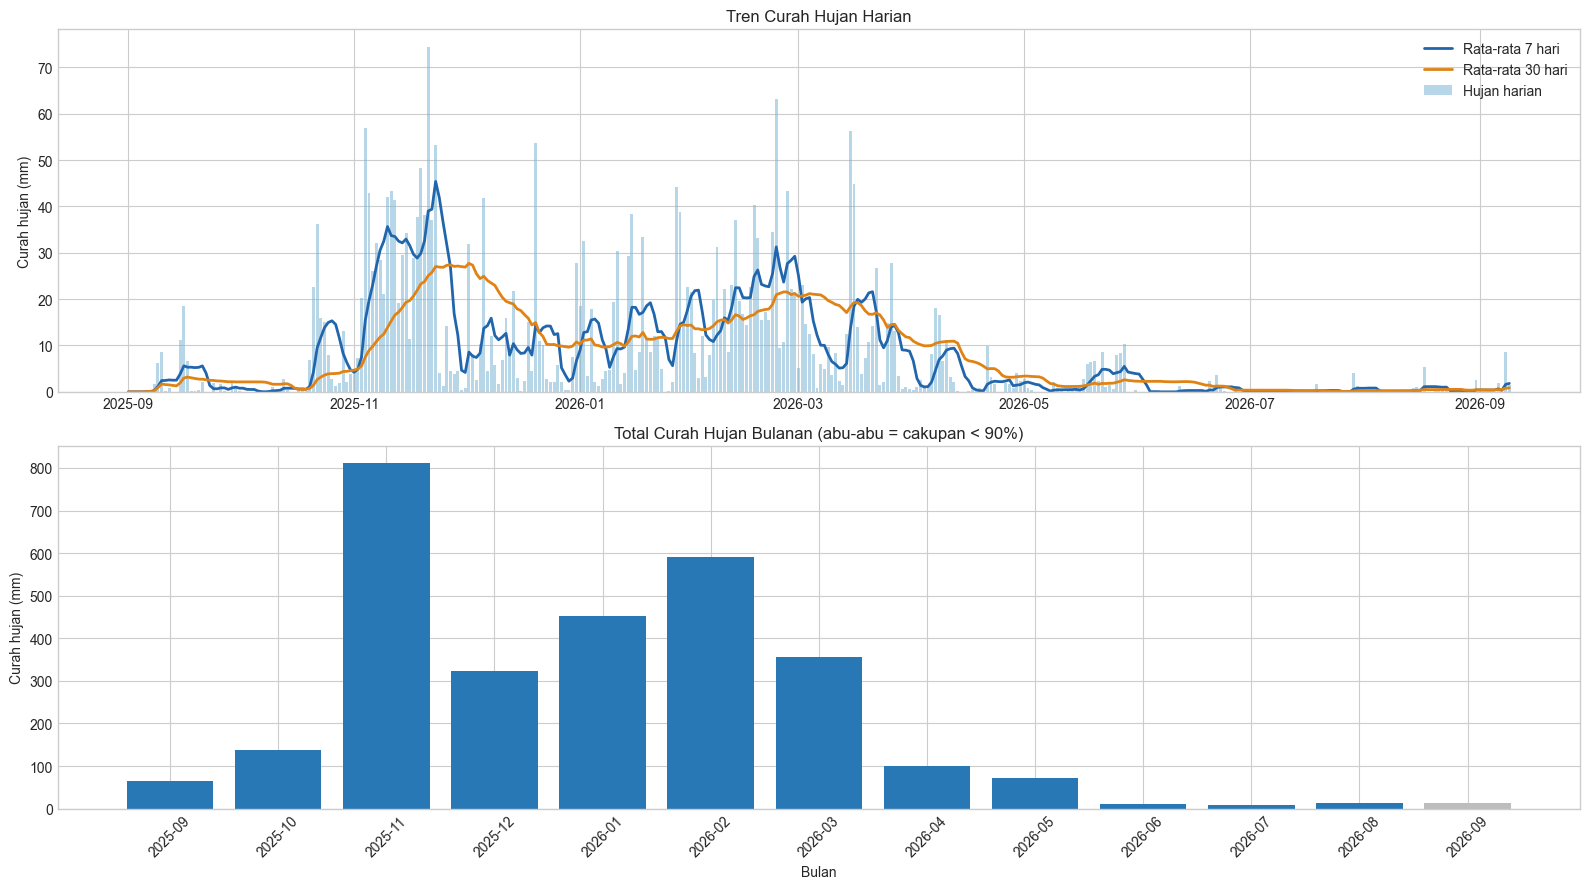

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

axes[0].bar(daily.index, daily["rain_mm"], color="#7db7d8", alpha=0.55, label="Hujan harian")
axes[0].plot(daily.index, daily["rain_7d_avg"], color="#2166ac", linewidth=2, label="Rata-rata 7 hari")
axes[0].plot(daily.index, daily["rain_30d_avg"], color="#e08214", linewidth=2, label="Rata-rata 30 hari")
axes[0].set_title("Tren Curah Hujan Harian")
axes[0].set_ylabel("Curah hujan (mm)")
axes[0].legend()

month_labels = monthly.index.strftime("%Y-%m")
bar_colors = np.where(monthly["coverage_pct"] >= 90, "#2878b5", "#bdbdbd")
axes[1].bar(month_labels, monthly["rain_mm"], color=bar_colors)
axes[1].set_title("Total Curah Hujan Bulanan (abu-abu = cakupan < 90%)")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("Curah hujan (mm)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Pola waktu kejadian hujan

Peluang hujan saat ini dan peluang hujan dalam tiga jam berikutnya dihitung untuk setiap jam. Pola ini dapat memotivasi fitur waktu siklik seperti `sin(hour)` dan `cos(hour)`. Pola hari dalam minggu ditampilkan sebagai pemeriksaan, tetapi tidak otomatis berarti hubungan kausal.

In [33]:
hourly_pattern = (
    df.groupby("hour")
    .agg(
        observations=("rain", "count"),
        rain_probability_pct=("rain_event", lambda values: float(values.mean()) * 100),
        future_rain_probability_pct=("rain_event_next_3h", lambda values: float(values.mean()) * 100),
        average_rain_mm=("rain", "mean"),
        maximum_rain_mm=("rain", "max"),
    )
)
hourly_pattern["average_intensity_when_raining_mm"] = (
    df.loc[df["rain_event"] == True]
    .groupby("hour")["rain"]
    .mean()
)

weekday_pattern = (
    df.groupby(["day_of_week_num", "day_of_week"])
    .agg(
        observations=("rain", "count"),
        rain_probability_pct=("rain_event", lambda values: float(values.mean()) * 100),
        future_rain_probability_pct=("rain_event_next_3h", lambda values: float(values.mean()) * 100),
    )
    .reset_index()
    .sort_values("day_of_week_num")
)

display(hourly_pattern.round(3))

,observations,rain_probability_pct,future_rain_probability_pct,average_rain_mm,maximum_rain_mm,average_intensity_when_raining_mm
hour,,,,,,
0,374,17.647,29.144,0.116,7.800,0.655
1,374,15.241,27.273,0.101,5.700,0.665
2,374,24.064,21.123,0.098,4.000,0.408
3,374,18.449,18.984,0.089,3.800,0.481
4,374,14.973,18.182,0.121,9.100,0.811
5,374,13.904,22.460,0.118,12.100,0.852
6,374,11.765,31.283,0.088,6.100,0.748
7,374,11.230,36.364,0.078,9.900,0.690
8,374,16.578,43.850,0.044,1.100,0.263


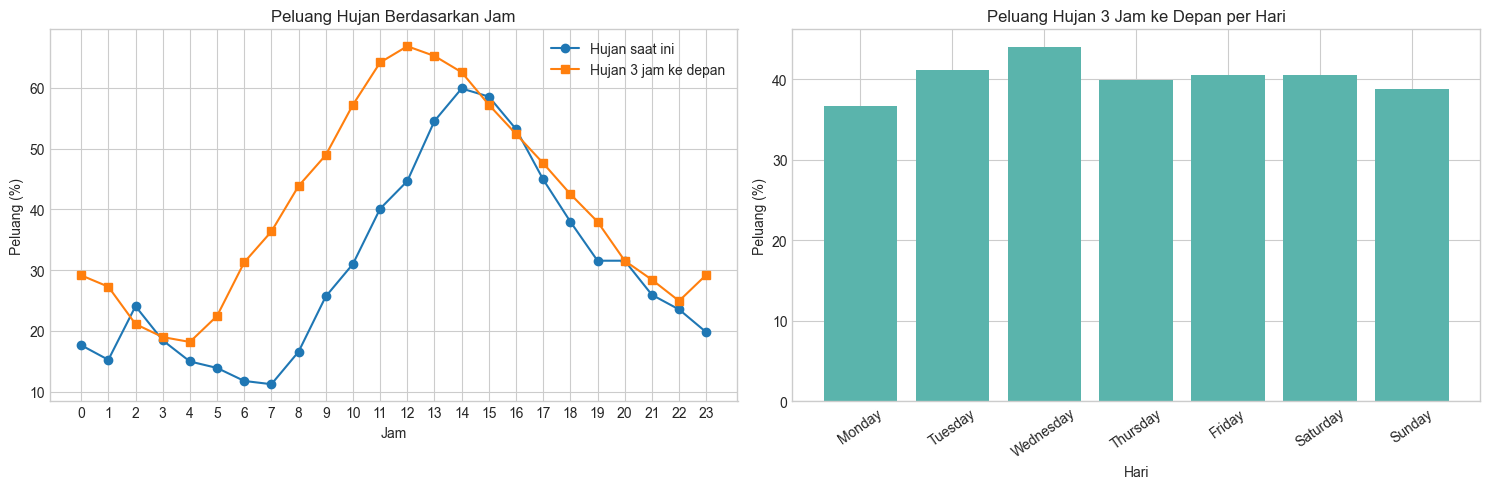

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(hourly_pattern.index, hourly_pattern["rain_probability_pct"], marker="o", label="Hujan saat ini")
axes[0].plot(hourly_pattern.index, hourly_pattern["future_rain_probability_pct"], marker="s", label="Hujan 3 jam ke depan")
axes[0].set_title("Peluang Hujan Berdasarkan Jam")
axes[0].set_xlabel("Jam")
axes[0].set_ylabel("Peluang (%)")
axes[0].set_xticks(range(24))
axes[0].legend()

axes[1].bar(weekday_pattern["day_of_week"], weekday_pattern["future_rain_probability_pct"], color="#5ab4ac")
axes[1].set_title("Peluang Hujan 3 Jam ke Depan per Hari")
axes[1].set_xlabel("Hari")
axes[1].set_ylabel("Peluang (%)")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 8. Hubungan kondisi cuaca dengan target

Korelasi Spearman digunakan karena hubungan cuaca tidak harus linear. Korelasi hanya menunjukkan asosiasi satu variabel dan tidak membuktikan sebab-akibat. `rain_next_3h_mm` sengaja tidak dimasukkan sebagai prediktor karena variabel tersebut adalah sumber langsung label target.

,korelasi_spearman
precipitation,0.654
rain,0.654
cloud_cover,0.435
pressure_msl,-0.394
temperature_2m,0.261
wind_direction_10m,-0.238
hour,0.085
relative_humidity_2m,0.067
wind_speed_10m,0.024


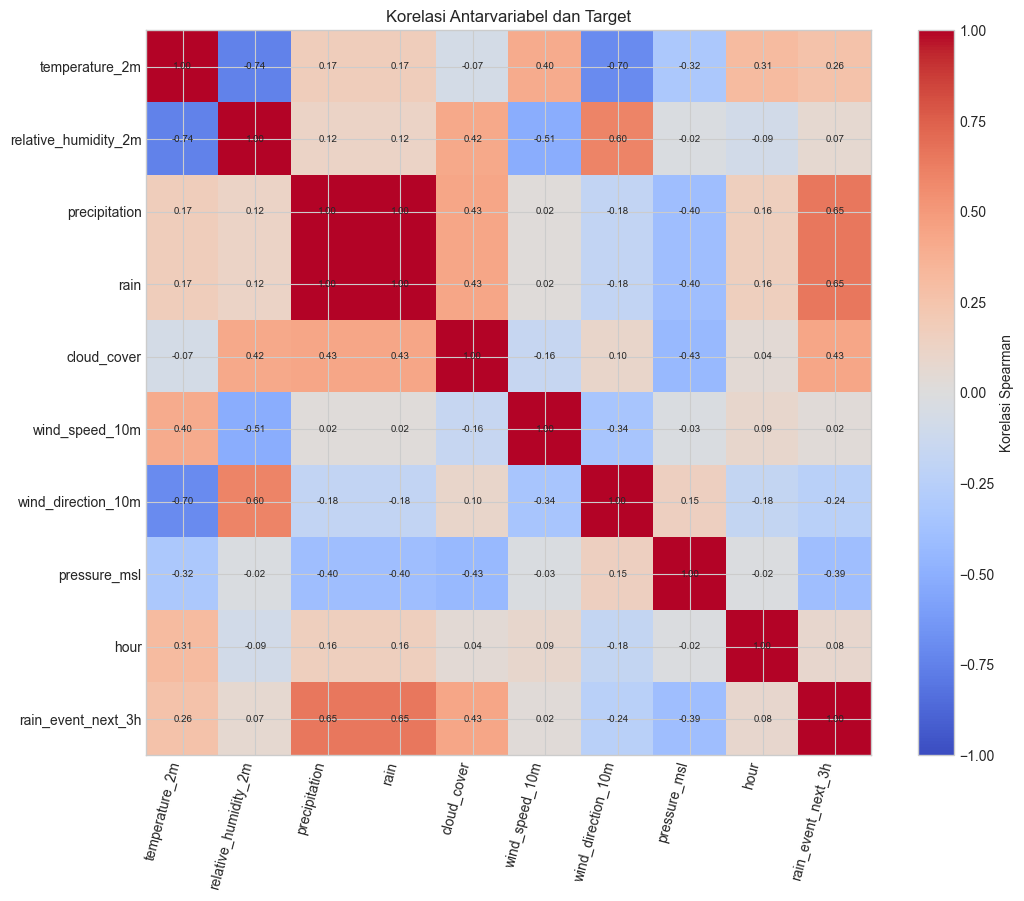

In [35]:
candidate_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "pressure_msl",
    "hour",
]

correlation_data = df[candidate_features].copy()
correlation_data["rain_event_next_3h"] = df["rain_event_next_3h"].astype("Float64")
correlation_matrix = correlation_data.corr(method="spearman")

target_correlations = (
    correlation_matrix["rain_event_next_3h"]
    .drop("rain_event_next_3h")
    .sort_values(key=abs, ascending=False)
)
display(target_correlations.to_frame("korelasi_spearman"))

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=75, ha="right")
ax.set_yticklabels(correlation_matrix.index)

for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(image, ax=ax, label="Korelasi Spearman")
ax.set_title("Korelasi Antarvariabel dan Target")
plt.tight_layout()
plt.show()

### Analisis berbasis kelompok kondisi

Setiap fitur dibagi menjadi lima kelompok kuantil. Tabel ini lebih mudah diinterpretasikan daripada korelasi saja: jika peluang target meningkat secara konsisten dari kelompok rendah ke tinggi, fitur tersebut berpotensi memiliki sinyal prediktif yang berguna.

In [36]:
features_to_group = [
    "relative_humidity_2m",
    "cloud_cover",
    "temperature_2m",
    "pressure_msl",
    "wind_speed_10m",
]

grouped_feature_insights = {}

for feature in features_to_group:
    analysis_data = df[[feature, "rain_event_next_3h", "rain_next_3h_mm"]].dropna().copy()
    analysis_data["feature_group"] = pd.qcut(
        analysis_data[feature],
        q=5,
        duplicates="drop",
    )

    result = (
        analysis_data.groupby("feature_group", observed=True)
        .agg(
            observations=(feature, "size"),
            average_feature_value=(feature, "mean"),
            rain_probability_pct=("rain_event_next_3h", lambda values: float(values.mean()) * 100),
            average_future_rain_mm=("rain_next_3h_mm", "mean"),
        )
        .round(3)
    )
    grouped_feature_insights[feature] = result

    print(f"\n{feature.upper()}")
    display(result)

current_rain_signal = (
    df.dropna(subset=["rain_event", "rain_event_next_3h"])
    .groupby("rain_event", observed=True)
    .agg(
        observations=("rain_event_next_3h", "size"),
        future_rain_probability_pct=("rain_event_next_3h", lambda values: float(values.mean()) * 100),
        average_future_rain_mm=("rain_next_3h_mm", "mean"),
    )
)
print("\nSinyal dari status hujan saat ini:")
display(current_rain_signal.round(3))


RELATIVE_HUMIDITY_2M


,observations,average_feature_value,rain_probability_pct,average_future_rain_mm
feature_group,,,,
"(24.999, 68.0]",1817,56.856,35.718,0.672
"(68.0, 83.0]",1862,76.522,52.739,2.101
"(83.0, 91.0]",1837,87.973,25.749,0.635
"(91.0, 96.0]",1837,94.003,30.593,0.456
"(96.0, 100.0]",1620,98.530,58.272,1.057



CLOUD_COVER


,observations,average_feature_value,rain_probability_pct,average_future_rain_mm
feature_group,,,,
"(-0.001, 33.0]",1820,14.610,10.879,0.088
"(33.0, 83.0]",1775,57.309,25.014,0.427
"(83.0, 99.0]",1828,94.772,37.856,0.908
"(99.0, 100.0]",3550,100.000,64.113,1.767



TEMPERATURE_2M


...

,observations,average_feature_value,rain_probability_pct,average_future_rain_mm
feature_group,,,,
"(1004.099, 1009.8]",1820,"1,008.635",65.989,1.981
"(1009.8, 1011.2]",1800,"1,010.590",52.889,1.335
"(1011.2, 1012.5]",1820,"1,011.880",42.527,0.989
"(1012.5, 1014.0]",1771,"1,013.274",26.934,0.482
"(1014.0, 1018.9]",1762,"1,015.282",11.691,0.108



WIND_SPEED_10M


,observations,average_feature_value,rain_probability_pct,average_future_rain_mm
feature_group,,,,
"(-0.001, 2.1]",1843,1.386,39.338,0.676
"(2.1, 3.2]",1848,2.717,37.662,0.795
"(3.2, 4.4]",1762,3.824,39.103,1.161
"(4.4, 6.2]",1732,5.252,44.053,1.307
"(6.2, 19.4]",1788,8.541,41.219,1.022



Sinyal dari status hujan saat ini:


,observations,future_rain_probability_pct,average_future_rain_mm
rain_event,,,
False,6255,19.329,0.214
True,2718,88.337,2.763


## 9. Kejadian ekstrem dan periode beruntun

Kejadian ekstrem penting untuk memeriksa outlier dan menentukan apakah performa model perlu dievaluasi secara terpisah pada hujan lebat. Streak hujan dan kering juga memberi gambaran mengenai persistensi kondisi cuaca.

In [37]:
extreme_columns = [
    "time",
    "rain",
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "pressure_msl",
]

print("Sepuluh jam dengan hujan tertinggi:")
display(df.nlargest(10, "rain")[extreme_columns].reset_index(drop=True))

print("Sepuluh hari dengan hujan tertinggi:")
display(
    daily.nlargest(10, "rain_mm")
    [["rain_mm", "rainy_hours", "max_hourly_rain_mm", "coverage_pct"]]
)

def calculate_streaks(flag: pd.Series, state_name: str) -> pd.DataFrame:
    streak_frame = flag.astype("boolean").rename("state").reset_index()
    # Hari tanpa data memutus streak dan tidak dihitung sebagai kondisi aktif.
    streak_frame["state"] = streak_frame["state"].fillna(False).astype(bool)
    streak_frame["group"] = streak_frame["state"].ne(streak_frame["state"].shift()).cumsum()

    streaks = (
        streak_frame.groupby("group")
        .agg(
            state=("state", "first"),
            start=("time", "min"),
            end=("time", "max"),
            days=("state", "size"),
        )
    )
    streaks = streaks.loc[streaks["state"]].copy()
    streaks["type"] = state_name
    return streaks.sort_values("days", ascending=False).reset_index(drop=True)

wet_streaks = calculate_streaks(daily["rainy_day"], "hujan")
dry_streaks = calculate_streaks(~daily["rainy_day"], "kering")

print("Periode hujan terpanjang:")
display(wet_streaks.head(5))
print("Periode kering terpanjang:")
display(dry_streaks.head(5))

Sepuluh jam dengan hujan tertinggi:


,time,rain,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,pressure_msl
0,2026-03-15 12:00:00,28.500,23.600,85,70,4.900,"1,011.600"
1,2025-11-18 13:00:00,21.000,24.300,84,100,5.800,"1,008.700"
2,2026-02-12 12:00:00,19.900,23.700,87,100,1.600,"1,011.000"
3,2025-11-06 12:00:00,18.100,26.600,75,100,4.900,"1,010.800"
4,2025-12-20 12:00:00,17.600,24.400,85,100,1.100,"1,008.700"
5,2026-02-17 15:00:00,17.500,25.600,79,100,5.600,"1,006.700"
6,2025-11-23 12:00:00,17.400,27.000,73,100,7.600,"1,008.400"
7,2025-11-04 10:00:00,16.800,26.900,70,99,10.100,"1,012.200"
8,2026-02-16 13:00:00,16.300,25.700,77,100,6.900,"1,007.700"
9,2026-01-27 11:00:00,16.100,25.800,76,100,3.300,"1,012.300"


Sepuluh hari dengan hujan tertinggi:


,rain_mm,rainy_hours,max_hourly_rain_mm,coverage_pct
time,,,,
2025-11-21,74.500,23,16.000,100.000
2026-02-23,63.100,23,12.900,100.000
2025-11-04,57.000,18,16.800,100.000
2026-03-15,56.200,11,28.500,100.000
2025-12-20,53.800,15,17.600,100.000
2025-11-23,53.200,19,17.400,100.000
2025-11-19,48.400,24,10.100,100.000
2026-03-16,44.900,16,14.900,100.000
2026-01-27,44.200,17,16.100,100.000


Periode hujan terpanjang:


,state,start,end,days,type
0,True,2025-10-17,2026-01-23,99,hujan
1,True,2026-01-25,2026-04-13,79,hujan
2,True,2026-05-13,2026-05-28,16,hujan
3,True,2026-04-26,2026-05-03,8,hujan
4,True,2025-09-15,2025-09-21,7,hujan


Periode kering terpanjang:


,state,start,end,days,type
0,True,2026-06-28,2026-07-17,20,kering
1,True,2026-06-01,2026-06-11,11,kering
2,True,2025-09-01,2025-09-05,5,kering
3,True,2025-10-02,2025-10-06,5,kering
4,True,2026-06-15,2026-06-19,5,kering


## 10. Ringkasan insight otomatis

Ringkasan berikut dihitung dari data sehingga tetap konsisten ketika periode atau lokasi diubah. Interpretasi bulan paling basah dan paling kering hanya memakai bulan dengan cakupan data minimal 90%.

In [38]:
complete_months = monthly.loc[monthly["coverage_pct"] >= 90]
months_for_summary = complete_months if not complete_months.empty else monthly

peak_month = months_for_summary["rain_mm"].idxmax()
driest_month = months_for_summary["rain_mm"].idxmin()
peak_current_hour = int(hourly_pattern["rain_probability_pct"].idxmax())
peak_future_hour = int(hourly_pattern["future_rain_probability_pct"].idxmax())
wettest_hour = df.loc[df["rain"].idxmax()]
strongest_signal = target_correlations.abs().idxmax()

print("RINGKASAN INSIGHT")
print("=" * 72)
print(f"Periode data                 : {df['time'].min()} s.d. {df['time'].max()}")
print(f"Cakupan observasi rain       : {df['rain'].notna().mean() * 100:.2f}%")
print(f"Persentase jam hujan         : {valid_current.mean() * 100:.2f}%")
print(f"Target positif 3 jam         : {positive_rate * 100:.2f}%")
print(f"Baseline kelas mayoritas     : {majority_baseline * 100:.2f}%")
print(f"Bulan paling basah           : {peak_month:%Y-%m} ({months_for_summary.loc[peak_month, 'rain_mm']:.2f} mm)")
print(f"Bulan paling kering          : {driest_month:%Y-%m} ({months_for_summary.loc[driest_month, 'rain_mm']:.2f} mm)")
print(f"Jam hujan saat ini tertinggi : {peak_current_hour:02d}:00")
print(f"Jam target 3 jam tertinggi   : {peak_future_hour:02d}:00")
print(f"Hujan per jam tertinggi      : {wettest_hour['rain']:.2f} mm pada {wettest_hour['time']}")
print(f"Streak hujan terpanjang      : {int(wet_streaks.iloc[0]['days'])} hari")
print(f"Streak kering terpanjang     : {int(dry_streaks.iloc[0]['days'])} hari")
print(f"Asosiasi univariat terkuat   : {strongest_signal} ({target_correlations[strongest_signal]:.3f})")

RINGKASAN INSIGHT
Periode data                 : 2025-09-01 00:00:00 s.d. 2026-09-09 23:00:00
Cakupan observasi rain       : 100.00%
Persentase jam hujan         : 30.28%
Target positif 3 jam         : 40.23%
Baseline kelas mayoritas     : 59.77%
Bulan paling basah           : 2025-11 (810.80 mm)
Bulan paling kering          : 2026-07 (7.40 mm)
Jam hujan saat ini tertinggi : 14:00
Jam target 3 jam tertinggi   : 12:00
Hujan per jam tertinggi      : 28.50 mm pada 2026-03-15 12:00:00
Streak hujan terpanjang      : 99 hari
Streak kering terpanjang     : 20 hari
Asosiasi univariat terkuat   : precipitation (0.654)


## 11. Implikasi untuk pemodelan

Berdasarkan struktur data dan tujuan prediksi, eksperimen model berikutnya sebaiknya mempertimbangkan hal-hal berikut:

- Gunakan pemisahan data secara kronologis, bukan random split, agar evaluasi meniru prediksi masa depan dan mencegah kebocoran waktu.
- Bandingkan model dengan baseline kelas mayoritas dan baseline persistensi, misalnya memprediksi hujan mendatang ketika sedang hujan sekarang.
- Gunakan metrik yang sesuai untuk kelas tidak seimbang: precision, recall, F1, PR-AUC, ROC-AUC, dan confusion matrix.
- Pertimbangkan fitur lag dan rolling yang hanya menggunakan masa lalu, seperti `rain_lag_1h`, perubahan tekanan, serta rata-rata kelembapan tiga jam terakhir.
- Representasikan jam dan arah angin sebagai fitur siklik menggunakan sinus dan kosinus.
- Periksa redundansi `rain` dan `precipitation` sebelum keduanya dimasukkan ke model.
- Jangan gunakan `rain_next_3h_mm` sebagai fitur karena variabel tersebut membentuk label target secara langsung.
- Karena data hanya mencakup sekitar satu tahun, pola musiman harus dianggap indikatif sampai tersedia data beberapa tahun.